# 🔬 Digital Forensics Tampering Detector
## Experimentation & Validation Notebook

**Project:** M.Sc Final Year Project  
**Company:** Brainybeam Info-Tech PVT LTD  
**Technology:** Data Science & Machine Learning With Data Analytics  
**Tools:** Jupyter Notebook / JupyterLab  
**Language:** Python – Primary language  

---

### Abstract
This project develops a computer vision-based system capable of detecting digital tampering in images and documents used as evidence. The system analyzes noise patterns, compression artifacts, and pixel inconsistencies to identify manipulated regions. Metadata validation helps uncover editing history or suspicious file alterations. The system highlights forged or modified sections with detailed forensic markings, strengthening digital evidence authentication.

---

### 📋 Notebook Structure
| Cell | Section |
|------|---------|
| 1 | **Setup & Install** — Install all dependencies |
| 2 | **Imports** — Load all required libraries |
| 3 | **Load Test Image** — Load real or synthetic image |
| 4 | **Algorithm 1: ELA** — Error Level Analysis |
| 5 | **Algorithm 2: Noise** — Noise Pattern Analysis |
| 6 | **Algorithm 3: Heatmap** — Forensic Heatmap |
| 7 | **Algorithm 4: EXIF** — Metadata Extraction |
| 8 | **Scoring & Verdict** — Combined forensic verdict |
| 9 | **Full Visual Report** — Complete report (saved as PNG) |
| 10 | **DEMO: Authentic vs Tampered** — Side-by-side example |
| 11 | **Summary** |

## 0. Setup & Install Dependencies

Run this cell once to install all required Python libraries.

In [2]:
# ── Install all required dependencies ──────────────────────────────────────
import subprocess, sys

packages = [
    "Pillow",
    "numpy",
    "scipy",
    "matplotlib",
]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "✅" if result.returncode == 0 else "❌"
    print(f"{status}  {pkg}")

print("\n🔬 All dependencies ready!")

✅  Pillow
✅  numpy
✅  scipy
✅  matplotlib

🔬 All dependencies ready!


## 1. Setup & Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from PIL import Image, ImageChops, ImageEnhance, ImageFilter, ImageDraw
from scipy.ndimage import gaussian_filter, uniform_filter
import io, json, base64, os, random
from IPython.display import display, HTML

# Pretty print versions
import PIL, scipy, matplotlib
print("✅ All libraries imported successfully!")
print(f"   NumPy     : {np.__version__}")
print(f"   Pillow    : {PIL.__version__}")
print(f"   SciPy     : {scipy.__version__}")
print(f"   Matplotlib: {matplotlib.__version__}")

✅ All libraries imported successfully!
   NumPy     : 2.1.3
   Pillow    : 11.0.0
   SciPy     : 1.14.1
   Matplotlib: 3.10.8


## 2. Load Test Image

You can either:
- Point `IMAGE_PATH` to a real image on disk (from `../test_images/`)
- Leave it as `None` to auto-generate a **synthetic tampered image** for demonstration

🔨 No path given — generating synthetic tampered demo image...
   Size: 500 × 380 px | Mode: RGB


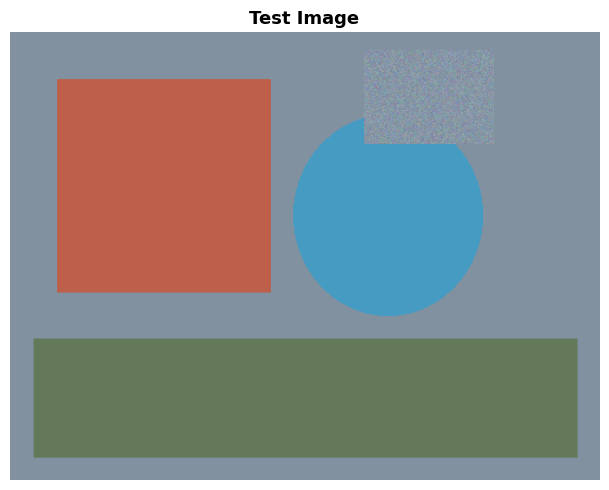

In [4]:
# ── CONFIGURATION ───────────────────────────────────────────────────────────
# Change this path to use a real image, or set to None for synthetic demo
IMAGE_PATH = None   # Example: "../test_images/02_photoshop_spliced.jpg"
# ────────────────────────────────────────────────────────────────────────────

def make_synthetic_tampered_image():
    """Create a synthetic image that simulates a tampered photo for demo."""
    # Background — simulates a real photo
    img = Image.new("RGB", (500, 380), color=(130, 145, 160))
    draw = ImageDraw.Draw(img)

    # Natural-looking shapes
    draw.rectangle([40, 40, 220, 220], fill=(190, 95, 75))
    draw.ellipse([240, 70, 400, 240], fill=(70, 155, 195))
    draw.rectangle([20, 260, 480, 360], fill=(100, 120, 90))

    # ── Simulate a pasted/tampered region ──────────────────────────────────
    # This patch has DIFFERENT noise from different compression
    tampered_w, tampered_h = 110, 80
    patch = Image.new("RGB", (tampered_w, tampered_h), color=(135, 150, 165))
    buf = io.BytesIO()
    patch.save(buf, format="JPEG", quality=60)   # Saved at DIFFERENT quality
    buf.seek(0)
    patch = Image.open(buf).convert("RGB")
    # Add pixel-level noise to make it distinguishable
    noise_arr = np.array(patch).astype(int)
    noise_arr += np.random.randint(-18, 18, noise_arr.shape)
    noise_arr = np.clip(noise_arr, 0, 255).astype(np.uint8)
    patch = Image.fromarray(noise_arr)
    img.paste(patch, (300, 15))
    # ────────────────────────────────────────────────────────────────────────

    return img

def load_test_image(path=None):
    """Load test image from disk or generate synthetic demo image."""
    if path and os.path.exists(path):
        img = Image.open(path)
        print(f"📂 Loaded image from: {path}")
        return img
    print("🔨 No path given — generating synthetic tampered demo image...")
    return make_synthetic_tampered_image()

image = load_test_image(IMAGE_PATH)
print(f"   Size: {image.size[0]} × {image.size[1]} px | Mode: {image.mode}")

plt.figure(figsize=(7, 5))
plt.imshow(image)
plt.title("Test Image", fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Error Level Analysis (ELA)

### What is ELA?
ELA works by re-saving the image at a known JPEG quality level and comparing it against the original. 
- **Authentic regions** → consistent, uniform, low error (dark in ELA output)
- **Tampered regions** → different compression history → higher error → **bright patches**

> 💡 We use the **95th percentile** (not max) to score — a single bright outlier pixel can't corrupt the result.

ELA Score  : 49.80%
Result     : MEDIUM — Possible manipulation


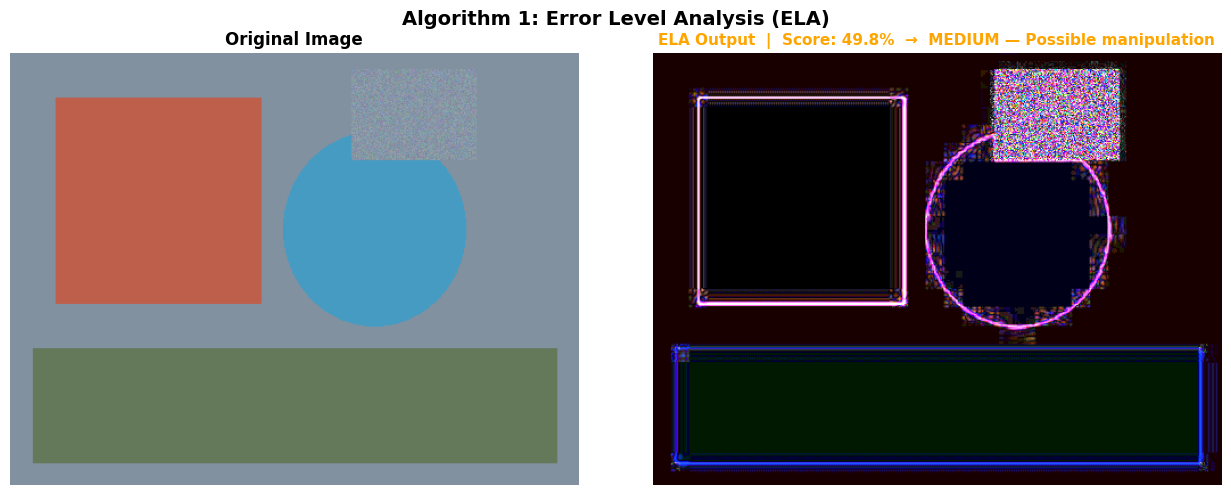

In [5]:
def perform_ela(image, quality=90):
    """
    Error Level Analysis (ELA).
    Re-saves image at quality=90 and computes pixel-level difference.
    Bright areas = higher error = more likely tampered.
    """
    img_rgb = image.convert("RGB")

    # Step 1: Re-save at controlled quality
    buffer = io.BytesIO()
    img_rgb.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    compressed = Image.open(buffer).convert("RGB")

    # Step 2: Pixel-level difference
    ela_image = ImageChops.difference(img_rgb, compressed)

    # Step 3: Amplify for visibility — CAPPED at 10× to prevent overexposure
    extrema = ela_image.getextrema()
    max_diff = max([e[1] for e in extrema])
    scale = (255.0 / max_diff) if max_diff > 0 else 1.0
    ela_image = ImageEnhance.Brightness(ela_image).enhance(min(scale, 10) * 5)
    #                                                        ↑ min(scale,10)
    #                                                        Prevents blowout on clean images

    # Step 4: Score = 95th percentile (robust, ignores outliers)
    ela_array = np.array(ela_image)
    ela_score = float(np.percentile(ela_array, 95) / 255.0 * 100)

    return ela_image, round(ela_score, 2)


ela_image, ela_score = perform_ela(image, quality=90)

# Interpret the score
if ela_score < 25:
    ela_label = "LOW — Image appears AUTHENTIC"
    ela_color = "green"
elif ela_score < 60:
    ela_label = "MEDIUM — Possible manipulation"
    ela_color = "orange"
else:
    ela_label = "HIGH — Strong tampering indicators"
    ela_color = "red"

print(f"ELA Score  : {ela_score:.2f}%")
print(f"Result     : {ela_label}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=12, fontweight="bold")
axes[0].axis("off")
axes[1].imshow(ela_image)
axes[1].set_title(f"ELA Output  |  Score: {ela_score:.1f}%  →  {ela_label}",
                  fontsize=11, fontweight="bold", color=ela_color)
axes[1].axis("off")
plt.suptitle("Algorithm 1: Error Level Analysis (ELA)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Noise Pattern Analysis

Every camera sensor has a unique noise "fingerprint". When a region is copy-pasted from a different source, it has a **different noise pattern**. We extract noise by subtracting the smoothed image and measure how much the local noise level varies across the image.

Noise Inconsistency Score : 23.75
Suspicious                : ✅ NO — noise is consistent


/tmp/ipykernel_6643/3410634448.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kamleshpatil/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


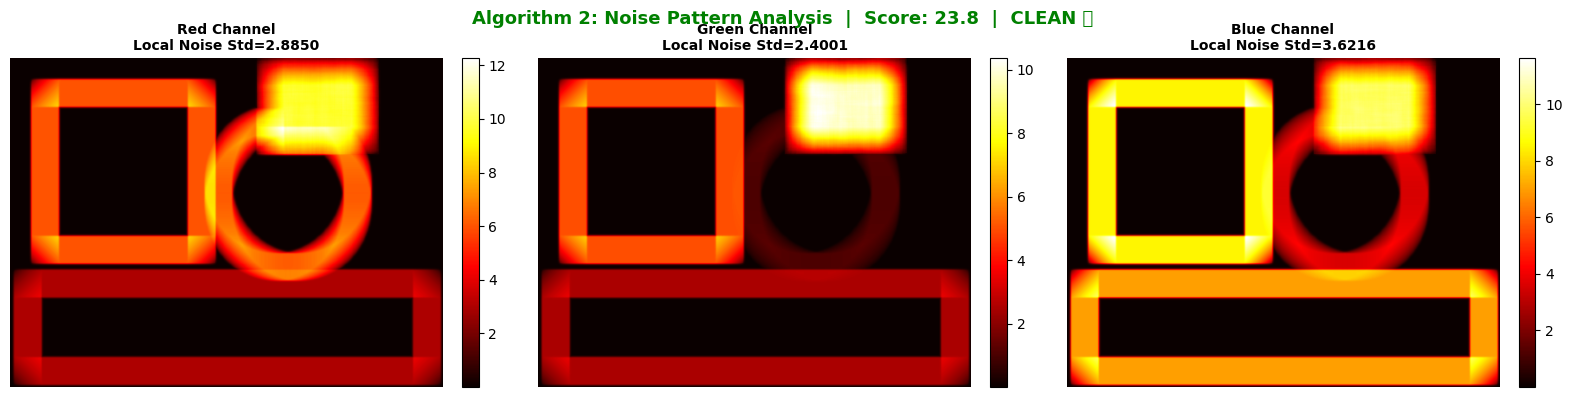

In [6]:
def analyze_noise(image):
    """
    Noise Pattern Analysis.
    Authentic images have consistent noise from the camera sensor.
    Spliced/tampered images show inconsistent noise across regions.
    """
    img_array = np.array(image.convert("RGB")).astype(float)
    scores = []
    noise_maps = []

    for ch in range(3):
        channel = img_array[:, :, ch]

        # Gaussian filter separates signal from noise (sigma=1.5 is forensic standard)
        smoothed = gaussian_filter(channel, sigma=1.5)
        noise = channel - smoothed

        # Local noise statistics in 32×32 windows
        local_mean    = uniform_filter(noise, size=32)
        local_sq_mean = uniform_filter(noise ** 2, size=32)
        local_var     = np.clip(local_sq_mean - local_mean ** 2, 0, None)
        local_std     = np.sqrt(local_var + 1e-6)

        # How varied is the local noise std? High variance = inconsistent = suspicious
        scores.append(float(np.std(local_std)))
        noise_maps.append(local_std)

    avg_score  = float(np.mean(scores))
    normalized = min(100.0, avg_score * 8)

    return round(normalized, 2), noise_maps


noise_score, noise_maps = analyze_noise(image)
noise_suspicious = noise_score > 25

print(f"Noise Inconsistency Score : {noise_score:.2f}")
print(f"Suspicious                : {'⚠️  YES — inconsistent sensor noise' if noise_suspicious else '✅ NO — noise is consistent'}")

channel_names = ["Red Channel", "Green Channel", "Blue Channel"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, nm, name in zip(axes, noise_maps, channel_names):
    im = ax.imshow(nm, cmap="hot")
    ax.set_title(f"{name}\nLocal Noise Std={np.std(nm):.4f}", fontsize=10, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"Algorithm 2: Noise Pattern Analysis  |  Score: {noise_score:.1f}  |  "
             f"{'SUSPICIOUS ⚠️' if noise_suspicious else 'CLEAN ✅'}",
             fontsize=13, fontweight="bold",
             color="red" if noise_suspicious else "green")
plt.tight_layout()
plt.show()

## 5. Forensic Heatmap Generation

Transforms the raw ELA output into a human-readable color overlay:
- 🔵 **Blue** → Clean region (low error)
- 🟡 **Yellow** → Mild anomaly
- 🔴 **Red** → Suspicious / tampered region

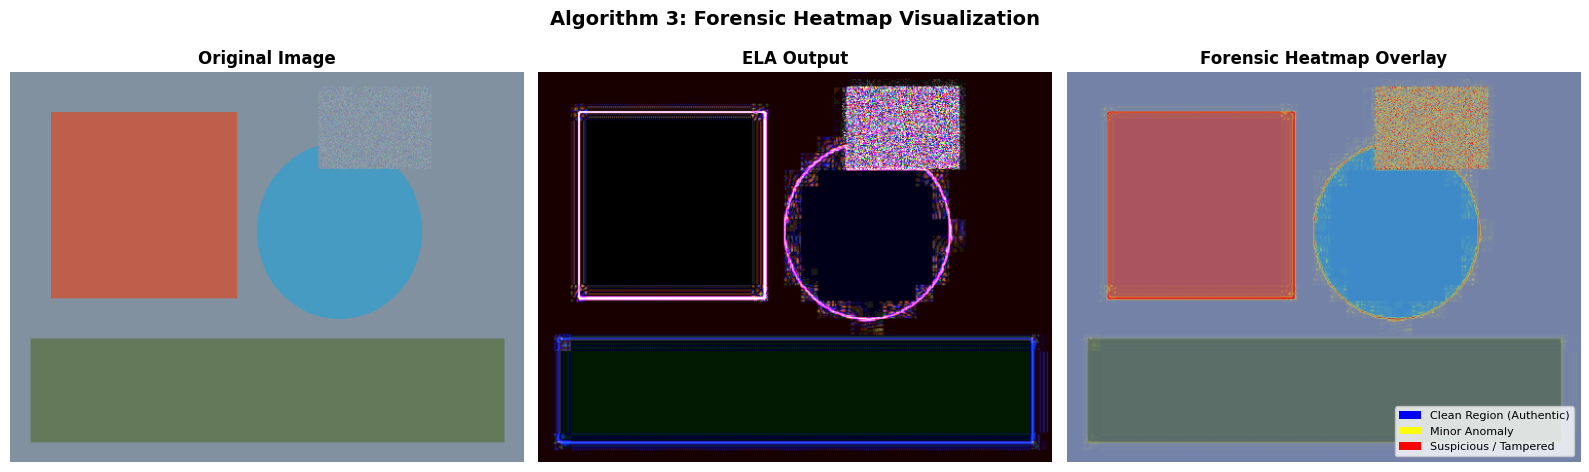

In [7]:
def generate_heatmap(ela_image):
    """Generate RGBA color-coded heatmap from ELA output. Blue→Yellow→Red."""
    ela_gray   = np.array(ela_image.convert("L")).astype(float)
    normalized = ela_gray / 255.0

    h, w = ela_gray.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)

    # Color mapping: Blue → Yellow → Red
    rgba[:, :, 0] = np.clip(normalized * 2 * 255, 0, 255).astype(np.uint8)           # R
    rgba[:, :, 1] = np.clip((1 - abs(normalized * 2 - 1)) * 255, 0, 255).astype(np.uint8)  # G
    rgba[:, :, 2] = np.clip((1 - normalized * 2) * 255, 0, 255).astype(np.uint8)     # B
    rgba[:, :, 3] = np.clip(normalized * 230, 40, 230).astype(np.uint8)              # Alpha

    return Image.fromarray(rgba, "RGBA")


heatmap = generate_heatmap(ela_image)

legend_handles = [
    Patch(facecolor="blue",   label="Clean Region (Authentic)"),
    Patch(facecolor="yellow", label="Minor Anomaly"),
    Patch(facecolor="red",    label="Suspicious / Tampered"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(ela_image)
axes[1].set_title("ELA Output", fontsize=12, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(image)
axes[2].imshow(heatmap, alpha=0.7)
axes[2].set_title("Forensic Heatmap Overlay", fontsize=12, fontweight="bold")
axes[2].legend(handles=legend_handles, loc="lower right", fontsize=8)
axes[2].axis("off")

plt.suptitle("Algorithm 3: Forensic Heatmap Visualization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. EXIF Metadata Extraction

Every digital photo has hidden **EXIF data** — camera make/model, date taken, GPS, and software used. When someone edits an image with Photoshop, GIMP, Lightroom etc., that software leaves its name behind in the metadata.

In [8]:
def extract_metadata(image, filename=""):
    """Extract and analyze EXIF metadata for tampering indicators."""
    metadata = {
        "format":       image.format or (filename.rsplit(".", 1)[-1].upper() if "." in filename else "UNKNOWN"),
        "mode":         image.mode,
        "width":        image.width,
        "height":       image.height,
        "size_display": f"{image.width} x {image.height} px",
    }

    exif_data, editing_software, suspicious_tags = {}, [], []

    try:
        from PIL.ExifTags import TAGS
        exif = image._getexif()
        if exif:
            for tag_id, value in exif.items():
                tag = TAGS.get(tag_id, str(tag_id))
                if isinstance(value, bytes):
                    try:    value = value.decode("utf-8", errors="ignore").strip("\x00")
                    except: value = value.hex()
                exif_data[str(tag)] = str(value)

            # Detect editing software
            sw = exif_data.get("Software", "").lower()
            for s in ["photoshop", "gimp", "lightroom", "paint.net",
                      "affinity", "illustrator", "capture one", "darktable"]:
                if s in sw:
                    editing_software.append(s.title())

            # Suspicious conditions
            if "DateTime" in exif_data and "DateTimeOriginal" in exif_data:
                if exif_data["DateTime"] != exif_data["DateTimeOriginal"]:
                    suspicious_tags.append("Modification date differs from original capture date")

            if not exif_data.get("Make") and not exif_data.get("Model"):
                suspicious_tags.append("No camera make/model recorded")

    except Exception:
        pass

    metadata.update({
        "exif":             exif_data,
        "has_exif":         len(exif_data) > 0,
        "editing_software": editing_software,
        "suspicious_tags":  suspicious_tags,
        "exif_count":       len(exif_data),
    })
    return metadata


meta = extract_metadata(image)

print("━" * 50)
print("EXIF METADATA REPORT")
print("━" * 50)
print(f"  Format           : {meta['format']}")
print(f"  Dimensions       : {meta['size_display']}")
print(f"  Color Mode       : {meta['mode']}")
print(f"  EXIF Fields      : {meta['exif_count']}")
print(f"  Editing Software : {meta['editing_software'] or 'None detected ✅'}")
print(f"  Suspicious Tags  : {meta['suspicious_tags'] or 'None ✅'}")

if meta["exif"]:
    print("\n  EXIF Data (first 15 fields):")
    for k, v in list(meta["exif"].items())[:15]:
        print(f"    {k:30s}: {str(v)[:60]}")
else:
    print("\n  ⚠️  No EXIF data found (image may be synthetic or stripped)")
print("━" * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXIF METADATA REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Format           : UNKNOWN
  Dimensions       : 500 x 380 px
  Color Mode       : RGB
  EXIF Fields      : 0
  Editing Software : None detected ✅
  Suspicious Tags  : None ✅

  ⚠️  No EXIF data found (image may be synthetic or stripped)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 7. Combined Scoring & Final Verdict

All 4 forensic signals are combined into a single score:

| Signal | Max Points |
|--------|-----------|
| ELA (JPEG) | 60 pts |
| Editing Software Detected | 30 pts |
| Noise Inconsistency | 20 pts |
| Suspicious EXIF Tags | 7.5 pts each |
| Missing EXIF (JPEG only) | 5 pts |

In [9]:
def compute_verdict(ela_score, noise_score, metadata):
    """Compute tampering probability and forensic verdict."""
    score_components = []
    indicators       = []

    # ELA contribution (max 60 pts) — lower weight for PNG/BMP (lossless formats)
    ela_weight = 0.3 if metadata.get("format", "").upper() in ["PNG", "BMP"] else 0.6
    score_components.append(min(60, ela_score * ela_weight))
    if ela_score > 30:
        indicators.append({
            "type": "ELA",
            "severity": "HIGH" if ela_score > 60 else "MEDIUM",
            "message": f"ELA score {ela_score:.1f}% — pixel manipulation detected"
        })

    # Editing software (30 pts)
    if metadata.get("editing_software"):
        score_components.append(30)
        indicators.append({
            "type": "SOFTWARE",
            "severity": "HIGH",
            "message": f"Editing software: {', '.join(metadata['editing_software'])}"
        })

    # Noise inconsistency (max 20 pts)
    score_components.append(min(20, noise_score * 0.2))
    if noise_score > 25:
        indicators.append({
            "type": "NOISE",
            "severity": "MEDIUM",
            "message": f"Noise inconsistency score: {noise_score:.1f} — possible splicing"
        })

    # Suspicious metadata tags (7.5 pts each)
    for tag in metadata.get("suspicious_tags", []):
        score_components.append(7.5)
        indicators.append({"type": "METADATA", "severity": "MEDIUM", "message": tag})

    # Missing EXIF on JPEG (5 pts)
    if not metadata.get("has_exif") and metadata.get("format", "").upper() in ["JPEG", "JPG", "TIFF"]:
        score_components.append(5)
        indicators.append({
            "type": "EXIF_MISSING",
            "severity": "LOW",
            "message": "No EXIF metadata — may have been stripped to hide editing history"
        })

    probability = min(100.0, sum(score_components))

    if probability < 20:
        verdict = "AUTHENTIC"
    elif probability < 50:
        verdict = "SUSPICIOUS"
    else:
        verdict = "TAMPERED"

    return verdict, round(probability, 1), indicators


verdict, probability, indicators = compute_verdict(ela_score, noise_score, meta)
verdict_colors = {"AUTHENTIC": "green", "SUSPICIOUS": "orange", "TAMPERED": "red"}
color = verdict_colors[verdict]

print("=" * 55)
print(f"  FORENSIC VERDICT       : {verdict}")
print(f"  Tampering Probability  : {probability}%")
print("=" * 55)
print(f"  ELA Score              : {ela_score:.1f}%")
print(f"  Noise Score            : {noise_score:.1f}")
print(f"  Indicators Triggered   : {len(indicators)}")
print("\n  Indicator Details:")
for ind in indicators:
    bar = "█" * (10 if ind["severity"] == "HIGH" else 6 if ind["severity"] == "MEDIUM" else 3)
    print(f"    [{ind['severity']:6s}] {ind['type']:15s}: {ind['message']}")
    print(f"             {bar}")
print("=" * 55)

  FORENSIC VERDICT       : SUSPICIOUS
  Tampering Probability  : 34.6%
  ELA Score              : 49.8%
  Noise Score            : 23.8
  Indicators Triggered   : 1

  Indicator Details:
    [MEDIUM] ELA            : ELA score 49.8% — pixel manipulation detected
             ██████


## 8. Full Visual Report

This generates a complete forensic analysis report as a single image — ready to show to evaluators.

/tmp/ipykernel_6643/2922353957.py:59: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=150, bbox_inches="tight", facecolor="white")
/home/kamleshpatil/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


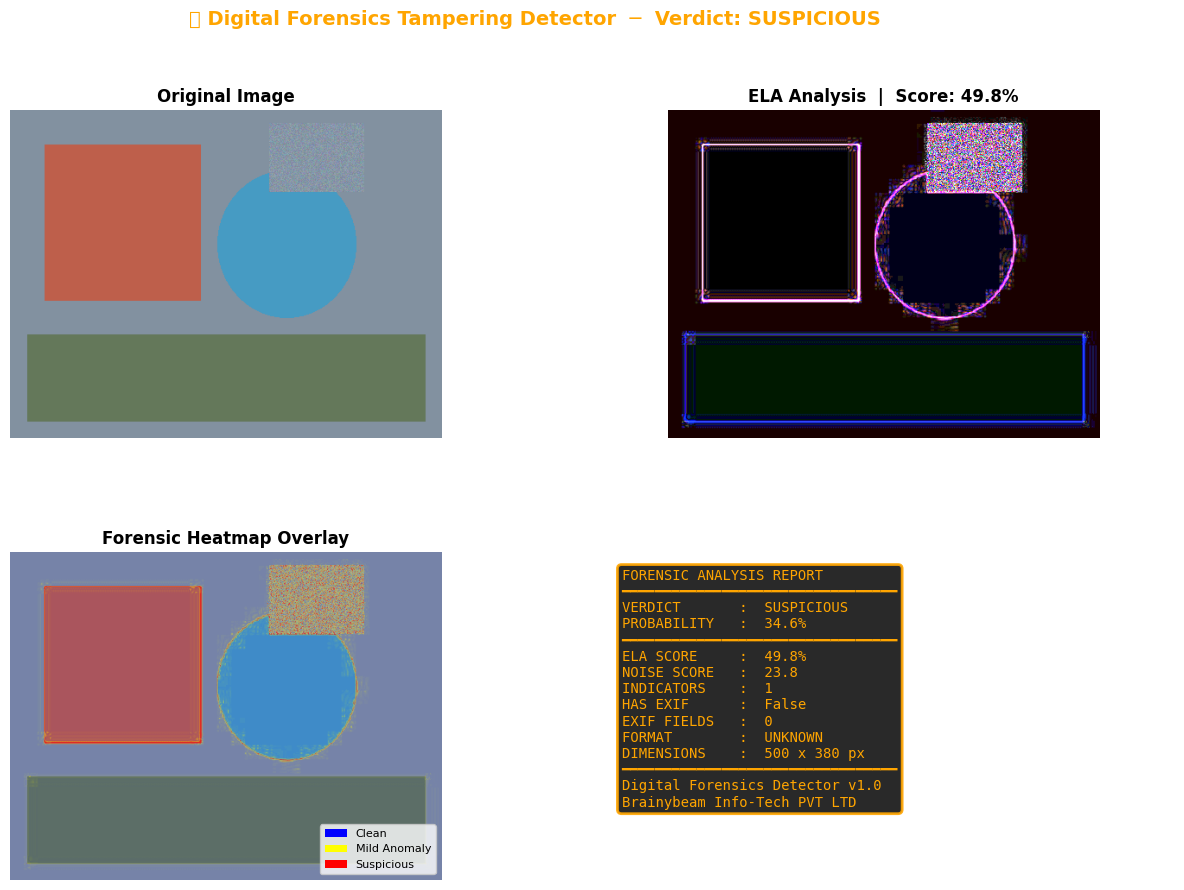


✅ Report saved as: forensic_report_output.png


In [10]:
color = verdict_colors[verdict]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.3)

# Panel 1: Original image
ax1 = fig.add_subplot(gs[0, :2])
ax1.imshow(image)
ax1.set_title("Original Image", fontsize=12, fontweight="bold")
ax1.axis("off")

# Panel 2: ELA output
ax2 = fig.add_subplot(gs[0, 2:])
ax2.imshow(ela_image)
ax2.set_title(f"ELA Analysis  |  Score: {ela_score:.1f}%", fontsize=12, fontweight="bold")
ax2.axis("off")

# Panel 3: Heatmap overlay
ax3 = fig.add_subplot(gs[1, :2])
ax3.imshow(image)
ax3.imshow(heatmap, alpha=0.65)
ax3.set_title("Forensic Heatmap Overlay", fontsize=12, fontweight="bold")
legend_handles = [
    Patch(facecolor="blue",   label="Clean"),
    Patch(facecolor="yellow", label="Mild Anomaly"),
    Patch(facecolor="red",    label="Suspicious"),
]
ax3.legend(handles=legend_handles, loc="lower right", fontsize=8)
ax3.axis("off")

# Panel 4: Summary report
ax4 = fig.add_subplot(gs[1, 2:])
ax4.axis("off")
summary = f"""FORENSIC ANALYSIS REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
VERDICT       :  {verdict}
PROBABILITY   :  {probability}%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ELA SCORE     :  {ela_score:.1f}%
NOISE SCORE   :  {noise_score:.1f}
INDICATORS    :  {len(indicators)}
HAS EXIF      :  {meta['has_exif']}
EXIF FIELDS   :  {meta['exif_count']}
FORMAT        :  {meta['format']}
DIMENSIONS    :  {meta['size_display']}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Digital Forensics Detector v1.0
Brainybeam Info-Tech PVT LTD"""

ax4.text(0.05, 0.95, summary, transform=ax4.transAxes,
         fontsize=10, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#111", alpha=0.9, edgecolor=color, lw=2),
         color=color)

fig.suptitle(f"🔬 Digital Forensics Tampering Detector  ─  Verdict: {verdict}",
             fontsize=14, fontweight="bold", color=color)

output_path = "forensic_report_output.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\n✅ Report saved as: {output_path}")

## 9. DEMO — Authentic vs Tampered Side-by-Side

This cell creates **two images from scratch** — one authentic, one tampered — and runs the full forensic pipeline on both. This is the best cell to show during your **college presentation** to make the algorithms clearly visible.

/tmp/ipykernel_6643/3338687688.py:94: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6643/3338687688.py:94: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6643/3338687688.py:95: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("demo_authentic_vs_tampered.png", dpi=150, bbox_inches="tight", facecolor="white")
/tmp/ipykernel_6643/3338687688.py:95: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig("demo_authentic_vs_tampered.png", dpi=150, bbox_inches="tight", facecolor="white")


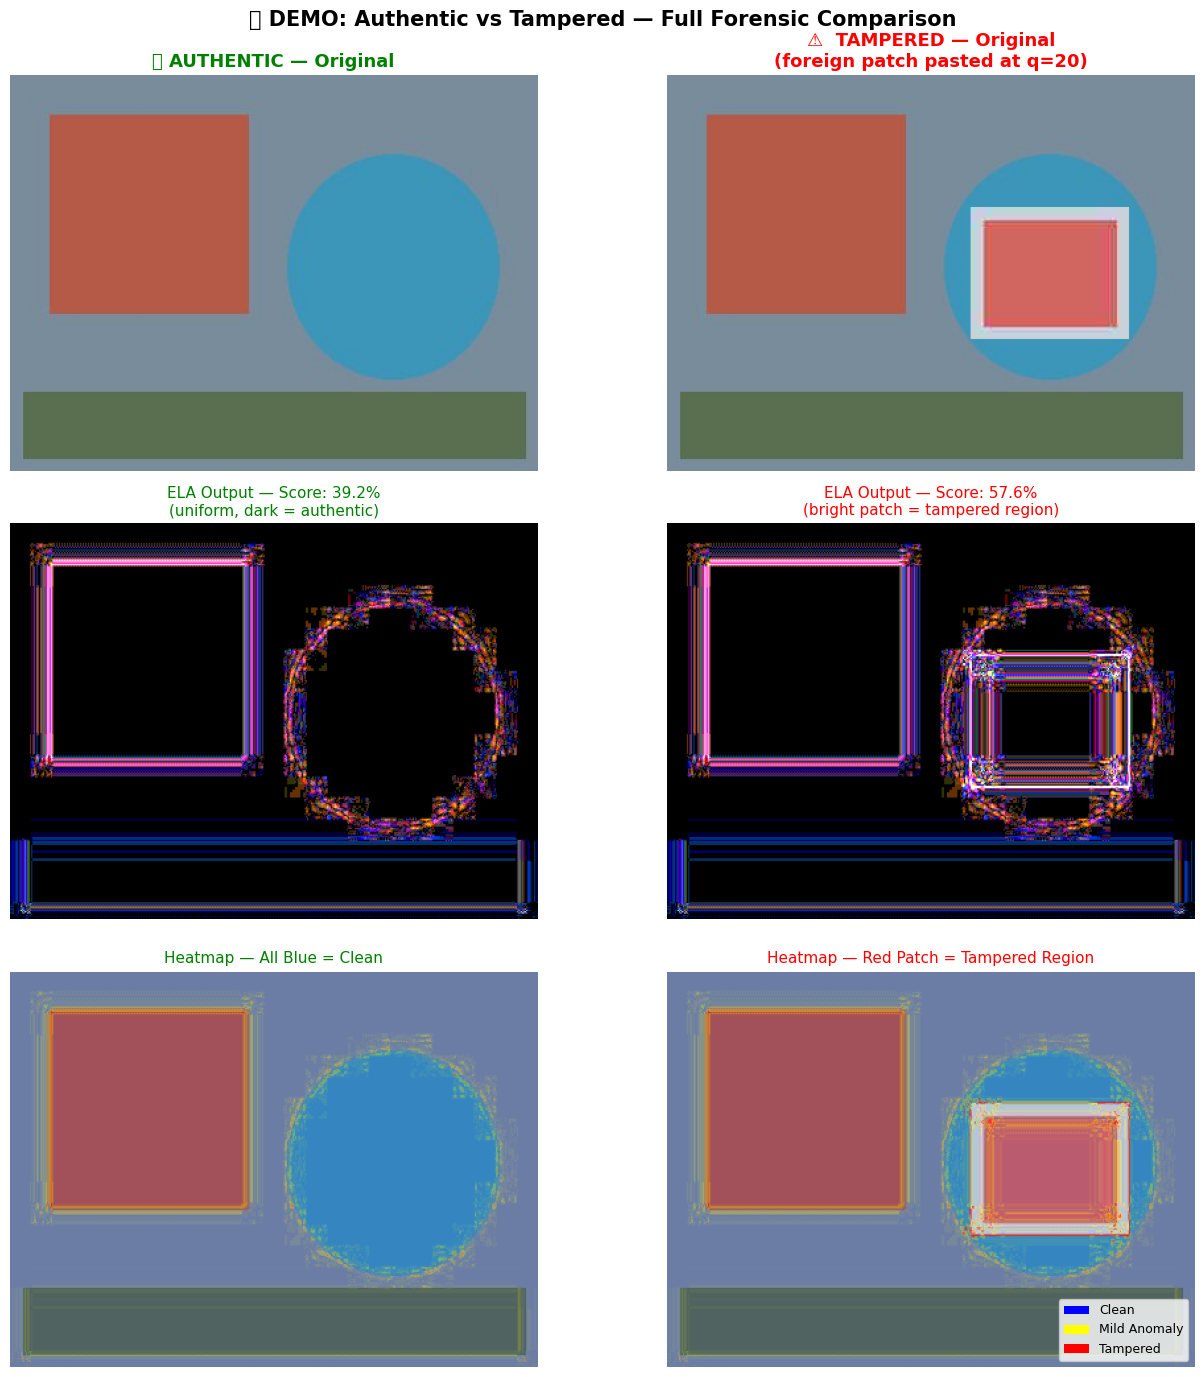


─────────────────────────────────────────────
  AUTHENTIC  ELA Score : 39.2%
  TAMPERED   ELA Score : 57.6%
─────────────────────────────────────────────
✅ Demo saved as: demo_authentic_vs_tampered.png


In [11]:
# ── Build an AUTHENTIC image ─────────────────────────────────────────────────
def make_authentic_image():
    """Simulate a clean, unedited camera photo with consistent JPEG history."""
    img = Image.new("RGB", (400, 300), color=(120, 140, 155))
    draw = ImageDraw.Draw(img)
    draw.rectangle([30, 30, 180, 180], fill=(180, 90, 70))
    draw.ellipse([210, 60, 370, 230], fill=(60, 150, 185))
    draw.rectangle([10, 240, 390, 290], fill=(90, 110, 80))
    # Simulate a camera — save at one single quality (consistent history)
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

# ── Build a TAMPERED image ───────────────────────────────────────────────────
def make_tampered_image():
    """Simulate a tampered image with a pasted region from a different source."""
    # Same base image saved at quality=85 (the 'original')
    img = Image.new("RGB", (400, 300), color=(120, 140, 155))
    draw = ImageDraw.Draw(img)
    draw.rectangle([30, 30, 180, 180], fill=(180, 90, 70))
    draw.ellipse([210, 60, 370, 230], fill=(60, 150, 185))
    draw.rectangle([10, 240, 390, 290], fill=(90, 110, 80))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    buf.seek(0)
    img = Image.open(buf).convert("RGB")

    # ── Paste a foreign patch saved at DIFFERENT quality (simulates Photoshop paste) ──
    patch_src = Image.new("RGB", (120, 100), color=(200, 210, 220))
    p_draw = ImageDraw.Draw(patch_src)
    p_draw.rectangle([10, 10, 110, 90], fill=(210, 100, 100))
    # Save patch at very different quality
    pbuf = io.BytesIO()
    patch_src.save(pbuf, format="JPEG", quality=20)  # Very low quality — different history
    pbuf.seek(0)
    patch = Image.open(pbuf).convert("RGB")
    img.paste(patch, (230, 100))  # Paste it in
    # ─────────────────────────────────────────────────────────────────────────
    return img

# ── Run forensics on both ────────────────────────────────────────────────────
img_auth    = make_authentic_image()
img_tamper  = make_tampered_image()

ela_auth,   score_auth   = perform_ela(img_auth)
ela_tamper, score_tamper = perform_ela(img_tamper)

hmap_auth   = generate_heatmap(ela_auth)
hmap_tamper = generate_heatmap(ela_tamper)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Row 1: Original images
axes[0][0].imshow(img_auth)
axes[0][0].set_title("✅ AUTHENTIC — Original", fontsize=13, fontweight="bold", color="green")
axes[0][0].axis("off")

axes[0][1].imshow(img_tamper)
axes[0][1].set_title("⚠️  TAMPERED — Original\n(foreign patch pasted at q=20)",
                     fontsize=13, fontweight="bold", color="red")
axes[0][1].axis("off")

# Row 2: ELA outputs
axes[1][0].imshow(ela_auth)
axes[1][0].set_title(f"ELA Output — Score: {score_auth:.1f}%\n(uniform, dark = authentic)",
                     fontsize=11, color="green")
axes[1][0].axis("off")

axes[1][1].imshow(ela_tamper)
axes[1][1].set_title(f"ELA Output — Score: {score_tamper:.1f}%\n(bright patch = tampered region)",
                     fontsize=11, color="red")
axes[1][1].axis("off")

# Row 3: Heatmap overlays
axes[2][0].imshow(img_auth)
axes[2][0].imshow(hmap_auth, alpha=0.65)
axes[2][0].set_title("Heatmap — All Blue = Clean", fontsize=11, color="green")
axes[2][0].axis("off")

axes[2][1].imshow(img_tamper)
axes[2][1].imshow(hmap_tamper, alpha=0.65)
axes[2][1].set_title("Heatmap — Red Patch = Tampered Region", fontsize=11, color="red")
axes[2][1].legend(handles=[
    Patch(facecolor="blue",   label="Clean"),
    Patch(facecolor="yellow", label="Mild Anomaly"),
    Patch(facecolor="red",    label="Tampered"),
], loc="lower right", fontsize=9)
axes[2][1].axis("off")

plt.suptitle("🔬 DEMO: Authentic vs Tampered — Full Forensic Comparison",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("demo_authentic_vs_tampered.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n{'─'*45}")
print(f"  AUTHENTIC  ELA Score : {score_auth:.1f}%")
print(f"  TAMPERED   ELA Score : {score_tamper:.1f}%")
print(f"{'─'*45}")
print("✅ Demo saved as: demo_authentic_vs_tampered.png")

## 10. Summary

### ✅ Key Techniques Used
| Algorithm | Type | Library |
|-----------|------|---------|
| **Error Level Analysis (ELA)** | Signal Processing — JPEG re-compression + pixel subtraction | `Pillow`, `NumPy` |
| **Noise Pattern Analysis** | Statistical Signal Theory — Gaussian filter + local variance | `SciPy`, `NumPy` |
| **EXIF Metadata Forensics** | Rule-Based Analysis — software detection + date check | `Pillow` |
| **Heatmap Visualization** | NumPy color mapping | `NumPy`, `Matplotlib` |

### ⚠️ What This Is NOT
This system does **not** use a pre-trained neural network or any ML model trained on a dataset. There is no training phase, no dataset, and no `.h5`/`.pkl` model file. These are **mathematically proven classical computer vision algorithms**.

### 🧪 How to Test
- To test on your own image: change `IMAGE_PATH` in **Cell 3** to a path from `../test_images/`
- `01_authentic_raw_photo.jpg` → should give low ELA score
- `02_photoshop_spliced.jpg` → should give high ELA score + software detected
- `04_heavy_clone_stamp.jpg` → should give high ELA + tampered heatmap

---
*This notebook was used for experimentation and validation of the forensic algorithms deployed in the full-stack web application.*  
**M.Sc Final Year Project · Brainybeam Info-Tech PVT LTD**